In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('matches_1930_2022.csv')
print("Data loaded successfully! Shape:", df.shape)

Data loaded successfully! Shape: (964, 44)


In [2]:
df['home_team'] = df['home_team'].str.strip()
df['away_team'] = df['away_team'].str.strip()
df['Host'] = df['Host'].str.strip()
df['total_goals'] = df['home_score'] + df['away_score']
def get_winner(row):
    if row['home_score'] > row['away_score']:
        return row['home_team']
    elif row['away_score'] > row['home_score']:
        return row['away_team']
    else:
        return 'Draw'

df['winner'] = df.apply(get_winner, axis=1)

yearly_trends = df.groupby('Year').agg(
    avg_goals=('total_goals', 'mean'),
    total_attendance=('Attendance', 'sum')
).reset_index()
top_countries = df[df['winner'] != 'Draw']['winner'].value_counts().head(10)

C:\Users\Zeeshan\AppData\Local\Temp\ipykernel_18556\2666646367.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis', ax=axes[0, 1])
C:\Users\Zeeshan\AppData\Local\Temp\ipykernel_18556\2666646367.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=goals_melted, x='Side', y='Goals', palette='Set2', ax=axes[1, 1])
C:\Users\Zeeshan\AppData\Local\Temp\ipykernel_18556\2666646367.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(['Home Team', 'Away Team'])


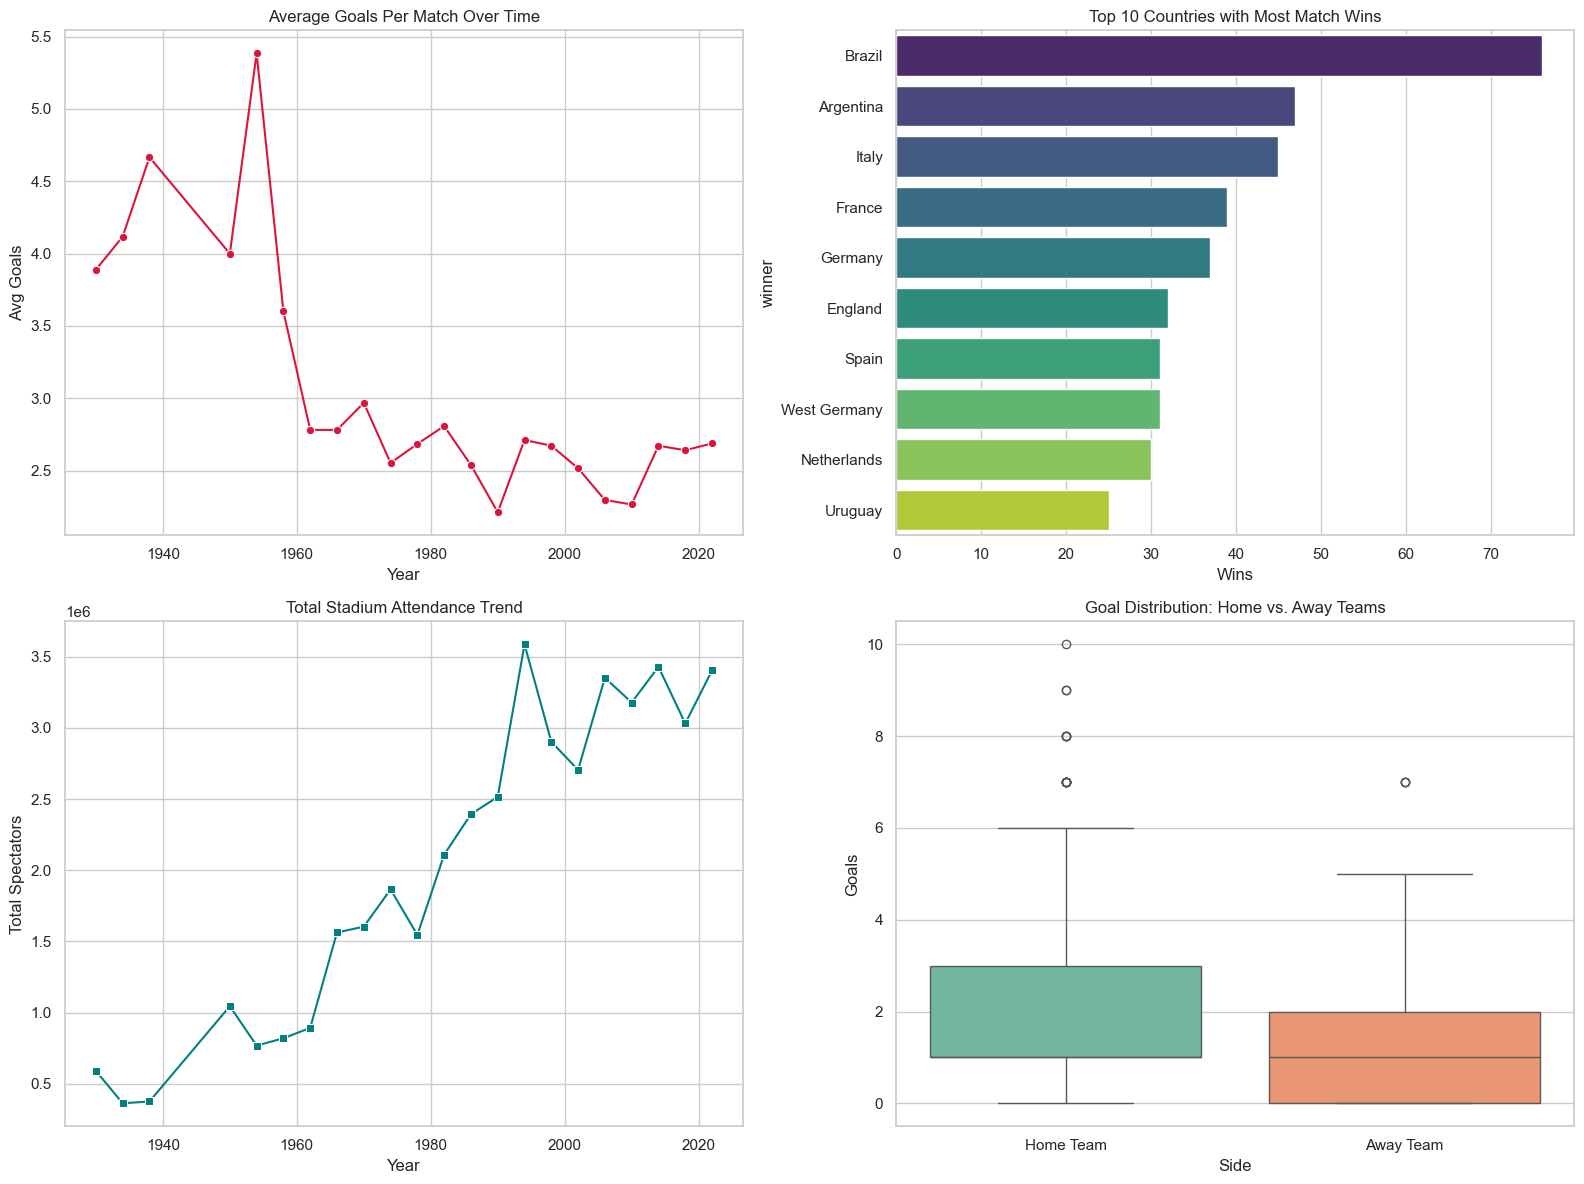

In [3]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.lineplot(data=yearly_trends, x='Year', y='avg_goals', marker='o', color='crimson', ax=axes[0, 0])
axes[0, 0].set_title('Average Goals Per Match Over Time')
axes[0, 0].set_ylabel('Avg Goals')
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis', ax=axes[0, 1])
axes[0, 1].set_title('Top 10 Countries with Most Match Wins')
axes[0, 1].set_xlabel('Wins')
sns.lineplot(data=yearly_trends, x='Year', y='total_attendance', marker='s', color='teal', ax=axes[1, 0])
axes[1, 0].set_title('Total Stadium Attendance Trend')
axes[1, 0].set_ylabel('Total Spectators')

goals_melted = pd.melt(df, value_vars=['home_score', 'away_score'], var_name='Side', value_name='Goals')
sns.boxplot(data=goals_melted, x='Side', y='Goals', palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Goal Distribution: Home vs. Away Teams')
axes[1, 1].set_xticklabels(['Home Team', 'Away Team'])
plt.tight_layout()
plt.savefig('world_cup_eda_plots.png', dpi=300)
plt.show()